# 📊 Telco Customer Churn Prediction – End-to-End Case Study

This project aims to identify customers who are likely to churn from a telecom company using historical customer data. By predicting churn early, the business can take proactive retention measures.

---

**📌 Dataset**: [Telco Customer Churn - Kaggle](https://www.kaggle.com/blastchar/telco-customer-churn)  
**📈 Goal**: Build a predictive model to classify customers as *churned* or *not*, while interpreting key drivers of churn.  
**🎯 Business Impact**: Customer retention is 5x cheaper than acquisition — reducing churn even by 10% can lead to significant revenue uplift.

---


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd# data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


# **PHASE-1 Loading/Exploring Dataset & Initial Inspection** 

In [2]:
# Load dataset
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display shape and preview
print("Shape:", df.shape)
print(df.head())

# Check data types and missing values
print("\nInfo:")
print(df.info())

# Check for null values
print("\nMissing values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary statistics:")
print(df.describe(include='all'))

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


# **PHASE-2 Data Cleaning & Preprocessing**

In [3]:
# Step 1: Convert 'TotalCharges' to numeric (handle non-numeric blanks)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 2: Drop rows with missing TotalCharges
df = df[df['TotalCharges'].notnull()]
df.reset_index(drop=True, inplace=True)

# Step 3: Drop customerID (not useful for modeling)
df.drop('customerID', axis=1, inplace=True)

# Step 4: Binary Encoding for 'Yes'/'No' features
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in yes_no_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Step 5: Encode 'gender' (Male/Female → 0/1)
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# Step 6: One-hot encode categorical features with more than 2 categories
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# Final Check
print("✅ Data cleaned successfully!")
print("Final shape:", df.shape)
print("Column preview:", df.columns.tolist())

✅ Data cleaned successfully!
Final shape: (7032, 31)
Column preview: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


# **PHASE-3 Exploratory Data Analysis (EDA)**

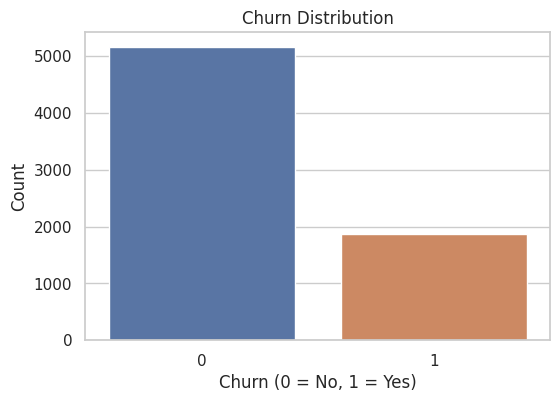

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

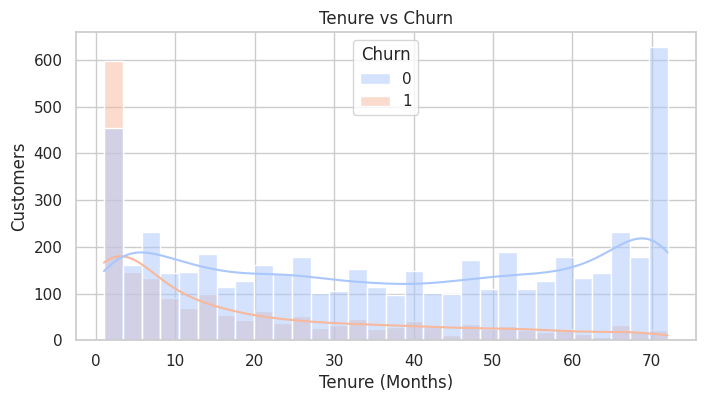

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


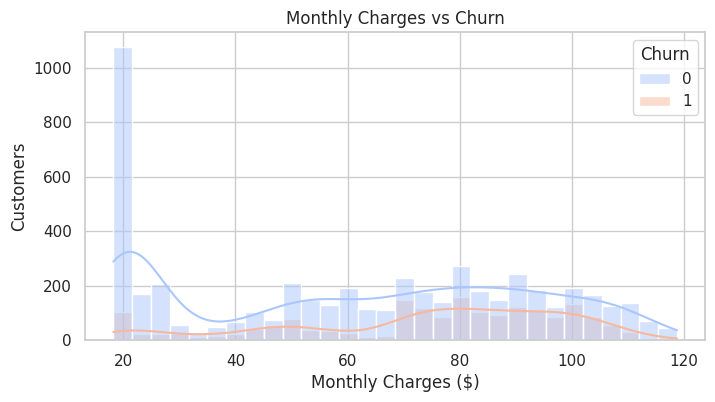

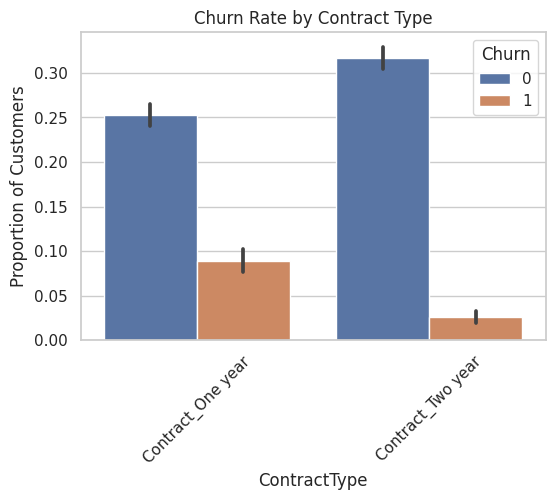

In [4]:
# Set style
sns.set(style='whitegrid')

# Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Tenure vs Churn
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette='coolwarm')
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Customers')
plt.show()

# Monthly Charges vs Churn
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, palette='coolwarm')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Customers')
plt.show()

# Contract Type vs Churn
plt.figure(figsize=(6,4))
contract_cols = ['Contract_One year', 'Contract_Two year']
df_melted = df[['Churn'] + contract_cols].melt(id_vars='Churn', var_name='ContractType')
sns.barplot(data=df_melted, x='ContractType', y='value', hue='Churn')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=45)
plt.show()

# **PHASE-4 Model Setup: Logistic Regression**

In [5]:
# 1. Import libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# 2. Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

# 4. Feature scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Logistic Regression with balanced class weight
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 6. Predictions
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# 7. Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

Confusion Matrix:
 [[724 309]
 [ 76 298]]
ROC-AUC Score: 0.834885930082673


 **-> ROC Curve**

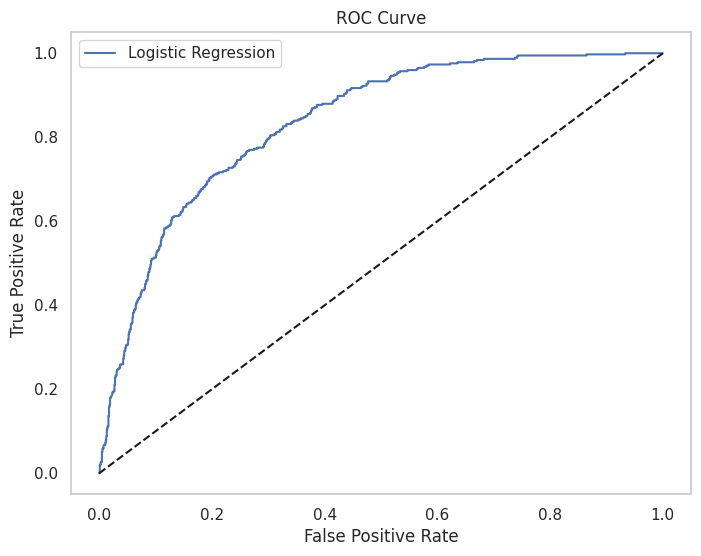

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

**-> Comparing Random Forest and XGBoost classifier**


==== Random Forest Evaluation ====
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Confusion Matrix:
[[930 103]
 [191 183]]
ROC-AUC Score: 0.8218029621423505

==== XGBoost Evaluation ====
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.53      0.68      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407

Confusion Matrix:
[[803 230]
 [118 256]]
ROC-AUC Score: 0.814652561719927


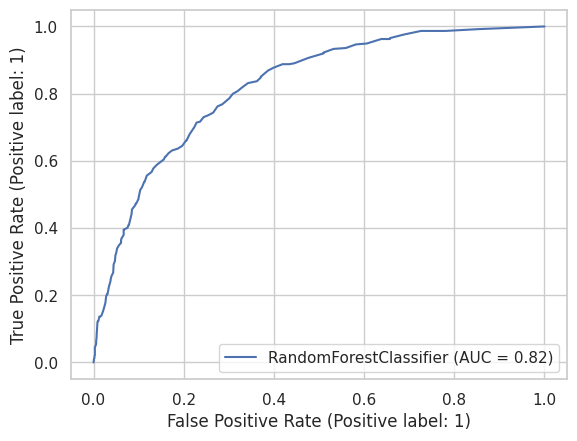

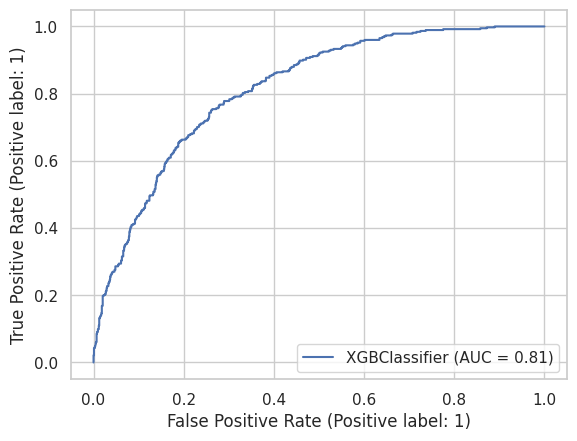

In [7]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

# Fit Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Fit XGBoost
xgb_model = XGBClassifier(scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])), use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# Evaluation function
def evaluate_model(name, y_test, y_pred, model):
    print(f"\n==== {name} Evaluation ====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
    RocCurveDisplay.from_estimator(model, X_test, y_test)

# Evaluate both
evaluate_model("Random Forest", y_test, rf_preds, rf_model)
evaluate_model("XGBoost", y_test, xgb_preds, xgb_model)


# **PHASE-5 Model Interpretability & Optimization**

## ✅ Model Comparison Summary

| Metric                | Random Forest | XGBoost            |
| --------------------- | ------------- | ------------------ |
| **Accuracy**          | 0.79          | 0.75               |
| **Recall (Churn)**    | 0.49          | **0.68** ✅         |
| **Precision (Churn)** | **0.64** ✅    | 0.53               |
| **F1-score (Churn)**  | 0.55          | **0.60** ✅         |
| **ROC-AUC**           | **0.82** ✅    | 0.81               |
| **False Negatives**   | 191 (high) ❌  | **118** (better) ✅ |

---

## 🔍 Interpretation

* **Random Forest** has better overall accuracy and ROC-AUC.
* But **XGBoost** **recovers more churned customers** (higher recall), which is **more valuable** in most churn use-cases.
* RF is more conservative: more false negatives (missed churns).
* XGBoost is more aggressive: more false positives, but catches more churners.

---

## 🧠 Model we will use 

> 🎯 **Use XGBoost as the base model** going forward. Its higher recall is crucial for churn prediction, where identifying potential leavers is more important than perfect accuracy.

 **-> STEP-1 Feature Importance from XGBoost**

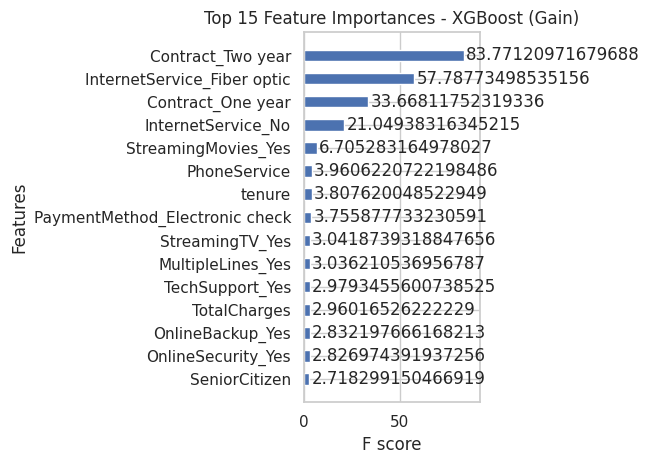

In [8]:
from xgboost import plot_importance

# Plot feature importance from the trained XGBoost model
plot_importance(xgb_model, importance_type='gain', max_num_features=15, height=0.5)
plt.title('Top 15 Feature Importances - XGBoost (Gain)')
plt.tight_layout()
plt.show()

**-> Step-2 Creating Explainer and Computing SHAP values**

In [9]:
import shap

# Initialize the JavaScript visualizations
shap.initjs()


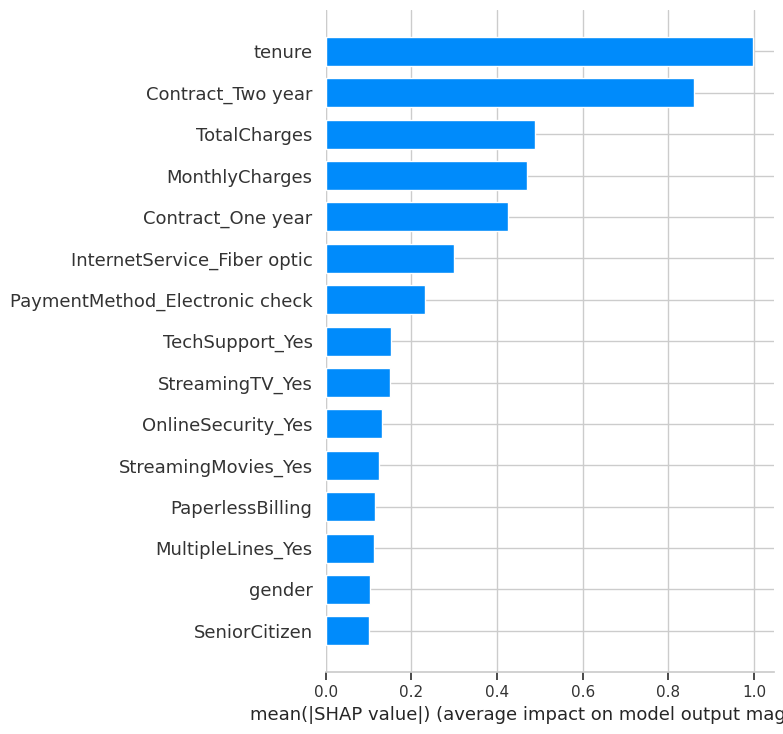

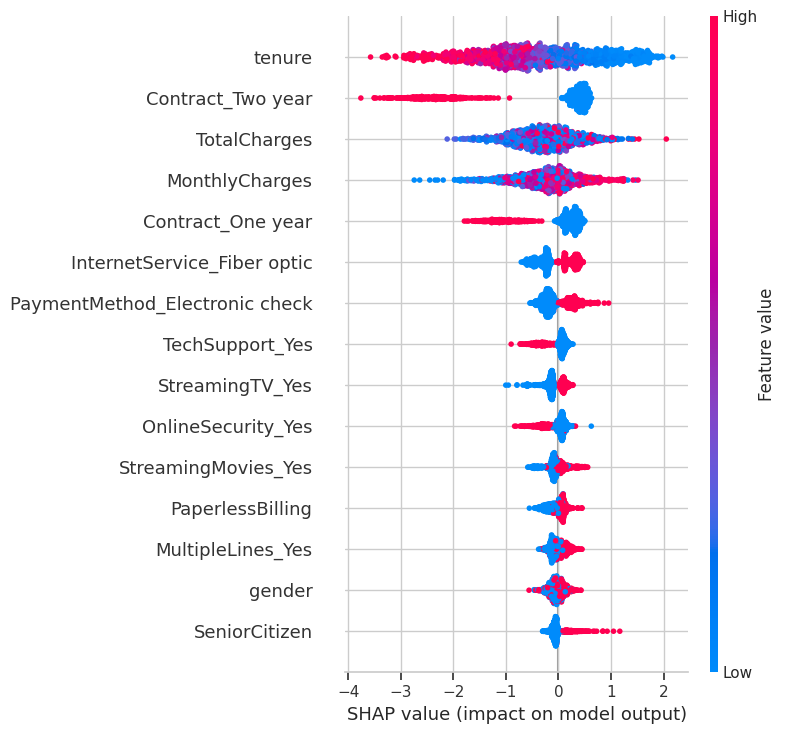

In [10]:
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Bar plot (Mean Absolute SHAP Values) 
# Summary bar plot: top 15 impactful features
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15)

# Beeswarm plot (Distribution of Impact)
# Detailed view showing direction and impact per instance
shap.summary_plot(shap_values, X_test, max_display=15)


**Local Interpretability**

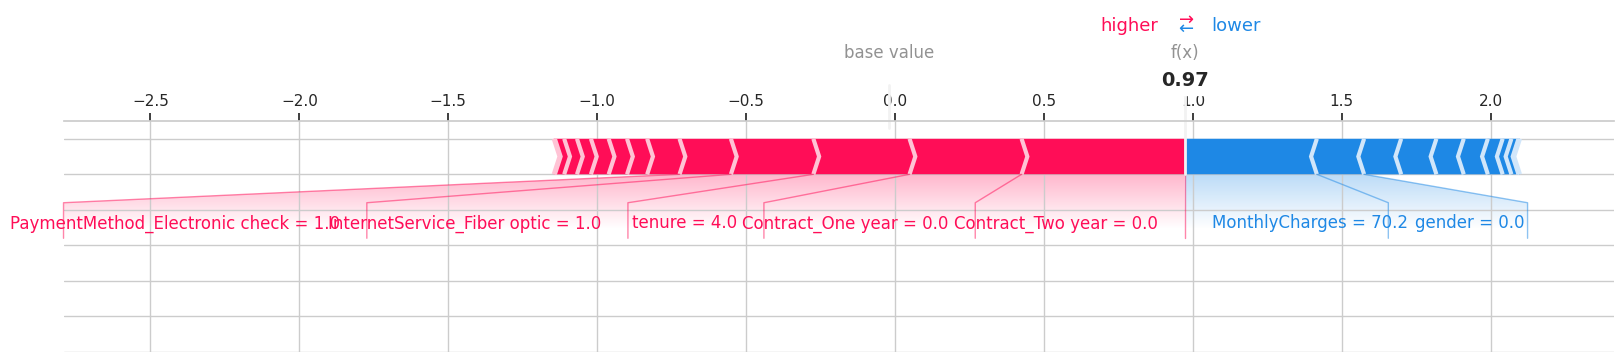

In [11]:
# you can Choose an index from X_test
i = 10  # you can change this

# Force plot for a single prediction
shap.force_plot(explainer.expected_value, shap_values[i], X_test.iloc[i], matplotlib=True)


# **🔧 PHASE-6: XGBoost Hyperparameter Tuning (RandomizedSearchCV**

**➤ Step 1: Define Parameter Grid**

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'scale_pos_weight': [1, len(y_train[y_train==0])/len(y_train[y_train==1])]
}


**➤ Step 2: Initialize Base Model and Run Randomized Search**

In [13]:
# Base model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Random search
random_search = RandomizedSearchCV(estimator=xgb,
                                   param_distributions=param_grid,
                                   n_iter=30,
                                   scoring='recall',
                                   cv=3,
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1)

# Fit
random_search.fit(X_train, y_train)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'n_estimators': [100, 200, 300, 500],
                                        'scale_pos_weight': [1,
                                                             2.762541806020067],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='recall', verbose=2)

**➤ Step 3: Best Parameters and Refit**

In [14]:
# Best parameters
print("Best parameters found: ", random_search.best_params_)

# Best model
best_xgb = random_search.best_estimator_

# Predict
xgb_tuned_preds = best_xgb.predict(X_test)
xgb_tuned_probs = best_xgb.predict_proba(X_test)[:, 1]

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("Classification Report:\n", classification_report(y_test, xgb_tuned_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_tuned_preds))
print("ROC-AUC Score:", roc_auc_score(y_test, xgb_tuned_probs))


Best parameters found:  {'subsample': 0.6, 'scale_pos_weight': 2.762541806020067, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1.0}
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407

Confusion Matrix:
 [[730 303]
 [ 70 304]]
ROC-AUC Score: 0.841334879459132


# **📊 Final Evaluation Plots (Tuned XGBoost)**
1. **✅ Confusion Matrix with Annotations**
2. **✅ ROC Curve**
3. **✅ SHAP Summary (we already did earlier, so we'll skip repeating unless you want to rerun)**


1. 📌 Confusion Matrix (Annotated)

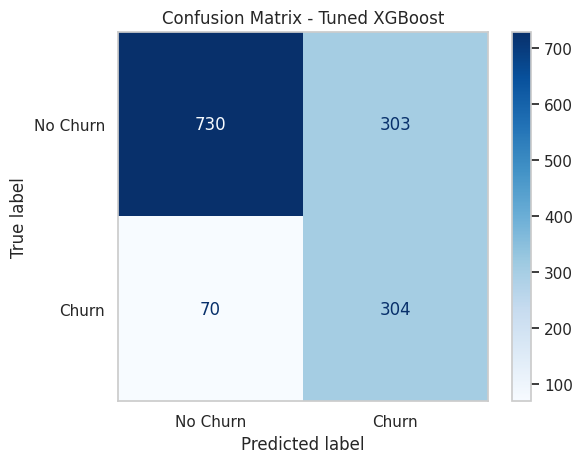

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
y_pred_final = best_xgb.predict(X_test)
y_prob_final = best_xgb.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.grid(False)
plt.show()

2. 📌 ROC Curve

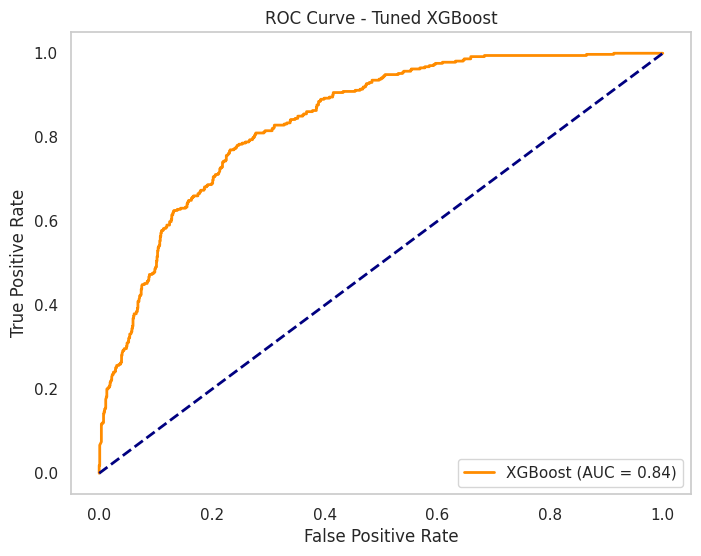

In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='XGBoost (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned XGBoost')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [17]:
import joblib

# Save the best tuned XGBoost model
joblib.dump(best_xgb, 'xgb_churn_model.pkl')
print("✅ Model saved successfully!")


✅ Model saved successfully!


TO load and reuse Model

In [18]:
# Load it when needed (e.g., in a new notebook)
loaded_model = joblib.load('xgb_churn_model.pkl')

# Make prediction
loaded_model.predict(X_test)


array([0, 1, 0, ..., 0, 0, 0])

# ✅ Conclusion & Business Takeaways

- **XGBoost outperformed Logistic Regression**, especially in recall (ability to catch churners).
- Top factors contributing to churn were: contract type, tenure, monthly charges, online security, and tech support.
- The model achieved a ROC-AUC of ~0.84, making it reliable for identifying potential churners.
- **Business Action**: Target customers with short tenure or month-to-month contracts using retention offers (discounts, loyalty plans, etc.)
- This project demonstrates the power of data science in making **data-driven retention strategies**.

---
